In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zoya77/breast-cancer-msi-multimodal-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-msi-multimodal-image-dataset' dataset.
Path to dataset files: /kaggle/input/breast-cancer-msi-multimodal-image-dataset


In [2]:
import shutil
import os

# Your downloaded path
src_path = path   # path returned by kagglehub
dst_path = "/content"

# Move / copy the dataset folder to /content
if os.path.exists(dst_path):
    print("Destination already exists, removing it first...")
    shutil.rmtree(dst_path)

shutil.copytree(src_path, dst_path)

print("Dataset copied to:", dst_path)


Destination already exists, removing it first...
Dataset copied to: /content


In [3]:
import pandas as pd

# Define base paths
base_path_xray = "/content/MultiModel Breast Cancer MSI Dataset/Chest_XRay_MSI"
categories_xray = ["Malignant", "Normal"]

base_path_hist = "/content/MultiModel Breast Cancer MSI Dataset/Histopathological_MSI"
categories_hist = ["benign", "malignant"]

base_path_ultra = "/content/MultiModel Breast Cancer MSI Dataset/Ultrasound Images_MSI"
categories_ultra = ["benign", "malignant"]

# Collect data
image_paths = []
labels = []
modality = []

# X-Ray
for category in categories_xray:
    category_path = os.path.join(base_path_xray, category)
    for image_name in os.listdir(category_path):
        image_paths.append(os.path.join(category_path, image_name))
        labels.append(category)
        modality.append("xray")

# Histopathology
for category in categories_hist:
    category_path = os.path.join(base_path_hist, category)
    for image_name in os.listdir(category_path):
        image_paths.append(os.path.join(category_path, image_name))
        labels.append(category)
        modality.append("histopath")

# Ultrasound
for category in categories_ultra:
    category_path = os.path.join(base_path_ultra, category)
    for image_name in os.listdir(category_path):
        image_paths.append(os.path.join(category_path, image_name))
        labels.append(category)
        modality.append("ultrasound")

# Create dataframe
df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels,
    "modality": modality
})

print(df.head())
print("Total samples:", len(df))


                                          image_path      label modality
0  /content/MultiModel Breast Cancer MSI Dataset/...  Malignant     xray
1  /content/MultiModel Breast Cancer MSI Dataset/...  Malignant     xray
2  /content/MultiModel Breast Cancer MSI Dataset/...  Malignant     xray
3  /content/MultiModel Breast Cancer MSI Dataset/...  Malignant     xray
4  /content/MultiModel Breast Cancer MSI Dataset/...  Malignant     xray
Total samples: 3052


In [4]:
df['label'].value_counts()

,count
label,
benign,1029
malignant,1023
Normal,500
Malignant,500


In [5]:
df.shape

(3052, 3)

In [6]:
df.columns

Index(['image_path', 'label', 'modality'], dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
image_path,0
label,0
modality,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3052 entries, 0 to 3051
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  3052 non-null   object
 1   label       3052 non-null   object
 2   modality    3052 non-null   object
dtypes: object(3)
memory usage: 71.7+ KB


In [10]:

df['label'].unique()

array(['Malignant', 'Normal', 'benign', 'malignant'], dtype=object)

In [11]:
df['label'].value_counts()

,count
label,
benign,1029
malignant,1023
Normal,500
Malignant,500


/tmp/ipython-input-490440602.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="viridis", ax=ax)


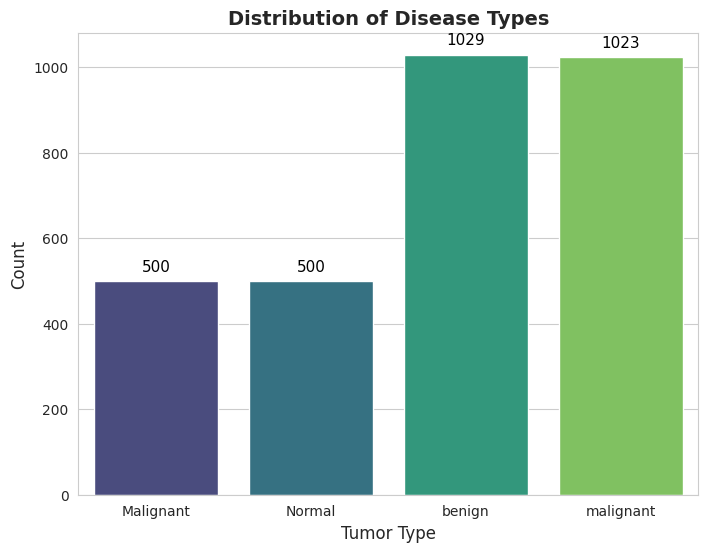

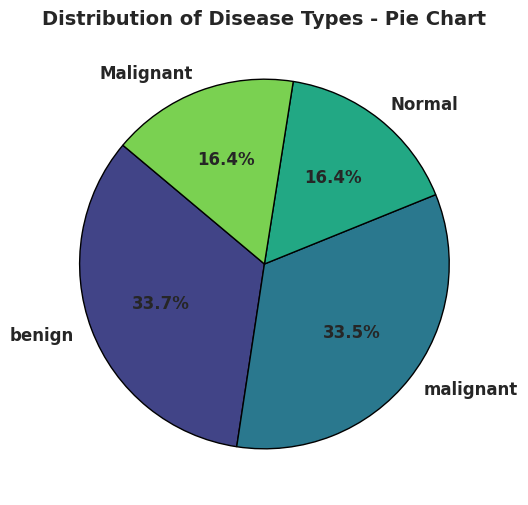

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x="label", palette="viridis", ax=ax)

ax.set_title("Distribution of Disease Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.show()

label_counts = df["label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", len(label_counts))

ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
       startangle=140, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'black', 'linewidth': 1})

ax.set_title("Distribution of Disease Types - Pie Chart", fontsize=14, fontweight='bold')

plt.show()

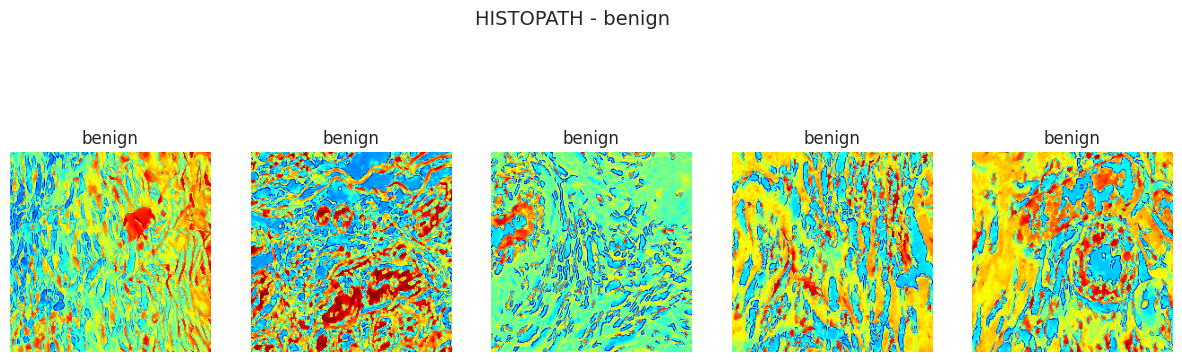

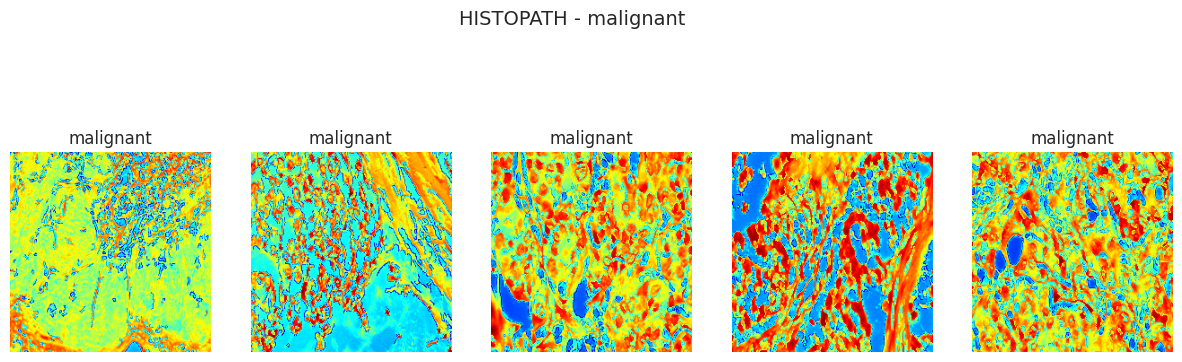

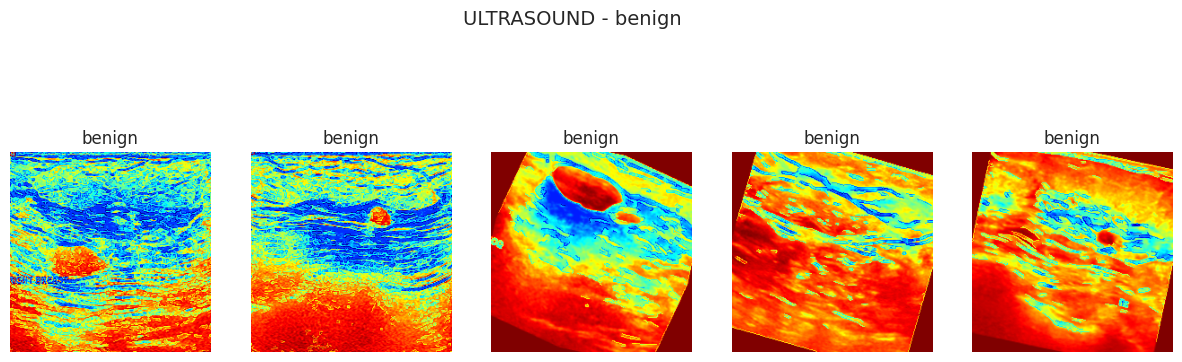

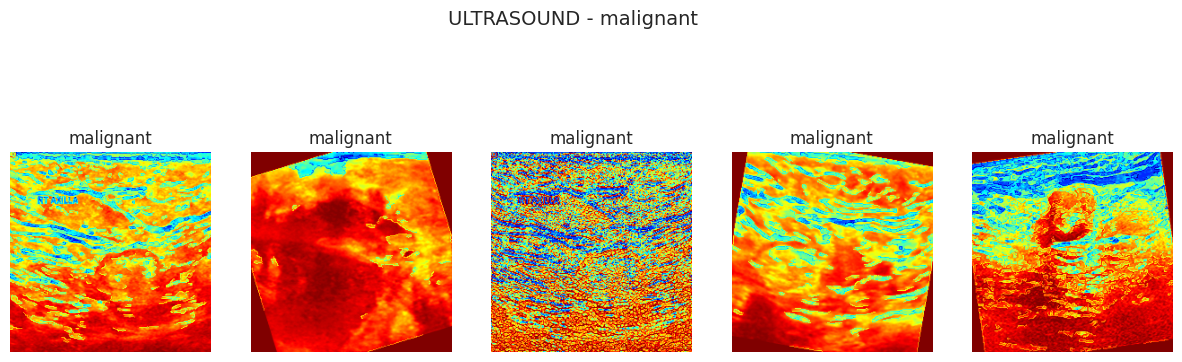

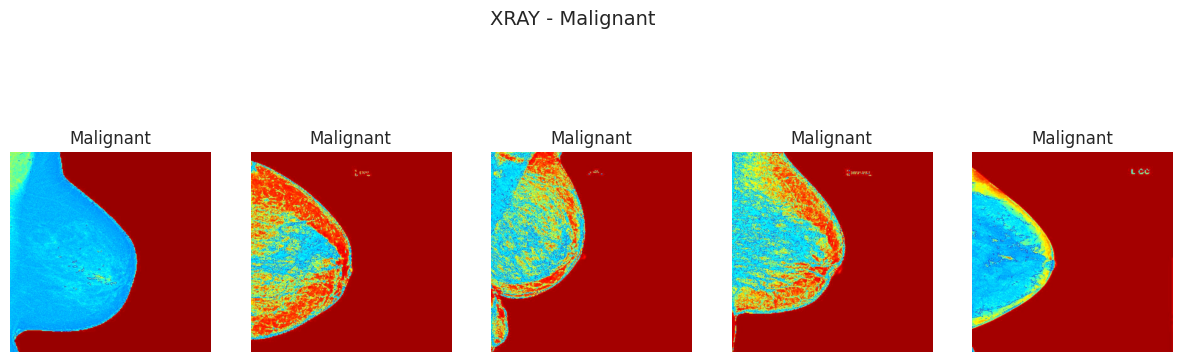

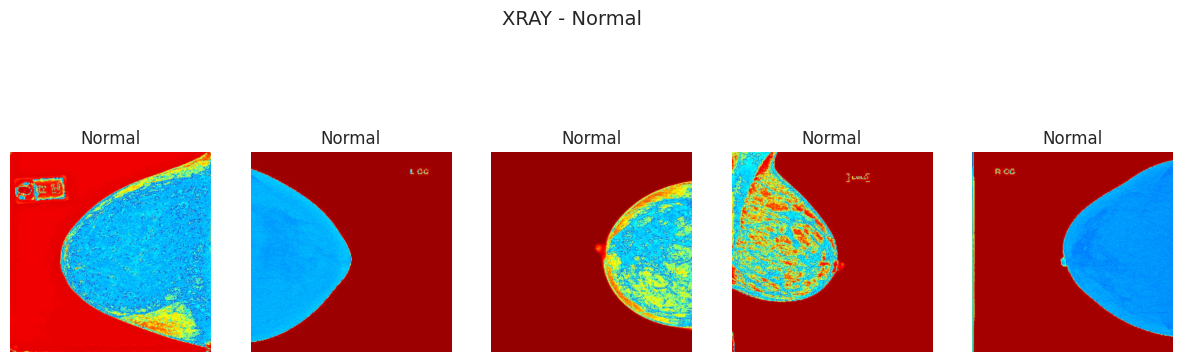

In [13]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# Get unique modality-label combinations
unique_groups = df.groupby(["modality", "label"])

for (modality, label), group in unique_groups:
    # Pick 5 random samples
    sample_paths = group.sample(n=5, random_state=42)["image_path"].tolist()

    # Plot
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(sample_paths):
        try:
            img = Image.open(img_path)
            plt.subplot(1, 5, i+1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{label}")
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    plt.suptitle(f"{modality.upper()} - {label}", fontsize=14)
    plt.show()


In [14]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Concatenate, Input, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [15]:
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder

# -------------------------
# Label Standardization
# -------------------------
def standardize_labels(labels):
    label_map = {
        "Normal": "benign",
        "Malignant": "malignant",
        "benign": "benign",
        "malignant": "malignant"
    }
    return [label_map[label] for label in labels]

# -------------------------
# Image Preprocessing
# -------------------------
def preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size)
        img = img / 255.0
        return img
    except Exception as e:
        print(f"Error reading {img_path}: {e}")
        return None

# -------------------------
# Loader for each modality
# -------------------------
def load_images(df, modality_name):
    images = []
    labels = []

    df_modality = df[df["modality"] == modality_name]   # filter by modality

    for _, row in df_modality.iterrows():
        img = preprocess_image(row['image_path'])
        if img is not None:   # only append if loaded successfully
            images.append(img)
            labels.append(row['label'])

    labels = standardize_labels(labels)
    return np.array(images), np.array(labels)

# -------------------------
# Load per modality
# -------------------------
xray_images, xray_labels   = load_images(df, "xray")
histo_images, histo_labels = load_images(df, "histopath")
ultra_images, ultra_labels = load_images(df, "ultrasound")

# -------------------------
# Encode labels globally
# -------------------------
le = LabelEncoder()
all_labels = np.concatenate([xray_labels, histo_labels, ultra_labels])
le.fit(all_labels)

xray_labels   = le.transform(xray_labels)
histo_labels  = le.transform(histo_labels)
ultra_labels  = le.transform(ultra_labels)

print("Label classes:", le.classes_)
print("X-ray:", xray_images.shape, xray_labels.shape)
print("Histopath:", histo_images.shape, histo_labels.shape)
print("Ultrasound:", ultra_images.shape, ultra_labels.shape)


Label classes: ['benign' 'malignant']
X-ray: (1000, 224, 224, 3) (1000,)
Histopath: (1246, 224, 224, 3) (1246,)
Ultrasound: (806, 224, 224, 3) (806,)


In [16]:
import cv2
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model



# =========================================================
# STEP 2: Data Augmentation for minority class (malignant)
# =========================================================
def augment_images(images, labels, target_class, target_count=1000):
    datagen = ImageDataGenerator(
        horizontal_flip=True,
        vertical_flip=True,
        rotation_range=20,
        zoom_range=0.2,
        fill_mode='nearest'
    )
    malignant_indices = np.where(labels == target_class)[0]
    if len(malignant_indices) == 0:
        print(f"No samples found for target class {target_class}. Skipping augmentation.")
        return images, labels

    malignant_images = images[malignant_indices]
    current_count = len(malignant_indices)
    augment_needed = target_count - current_count
    if augment_needed <= 0:
        print(f"Enough samples ({current_count}) for target class {target_class}. No augmentation needed.")
        return images, labels

    augmented_images = []
    augmented_labels = []
    for _ in range(augment_needed // current_count + 1):
        for img in malignant_images:
            img = img.reshape((1,) + img.shape)
            for batch in datagen.flow(img, batch_size=1):
                augmented_images.append(batch[0])
                augmented_labels.append(target_class)
                if len(augmented_images) >= augment_needed:
                    break
        if len(augmented_images) >= augment_needed:
            break

    augmented_images = np.array(augmented_images[:augment_needed])
    augmented_labels = np.array(augmented_labels[:augment_needed])
    return np.concatenate([images, augmented_images], axis=0), np.concatenate([labels, augmented_labels], axis=0)

malignant_class = le.transform(['malignant'])[0]
xray_images, xray_labels = augment_images(xray_images, xray_labels, target_class=malignant_class)
histo_images, histo_labels = augment_images(histo_images, histo_labels, target_class=malignant_class)
ultra_images, ultra_labels = augment_images(ultra_images, ultra_labels, target_class=malignant_class)

# Align dataset sizes across modalities
num_samples = min(len(xray_images), len(histo_images), len(ultra_images))
xray_images, xray_labels   = xray_images[:num_samples], xray_labels[:num_samples]
histo_images, histo_labels = histo_images[:num_samples], histo_labels[:num_samples]
ultra_images, ultra_labels = ultra_images[:num_samples], ultra_labels[:num_samples]

print("Dataset size after augmentation:", num_samples)
print("Label distribution after augmentation:", pd.Series(le.inverse_transform(xray_labels)).value_counts())



Dataset size after augmentation: 1406
Label distribution after augmentation: malignant    906
benign       500
Name: count, dtype: int64


In [17]:
# =========================================================
# STEP 3: Feature Extraction using ResNet50
# =========================================================
def build_feature_extractor():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    model = Model(inputs=base_model.input, outputs=x)
    return model

def extract_features(images, model):
    features = model.predict(images, batch_size=16, verbose=1)
    return features

xray_extractor  = build_feature_extractor()
histo_extractor = build_feature_extractor()
ultra_extractor = build_feature_extractor()

xray_features  = extract_features(xray_images, xray_extractor)
histo_features = extract_features(histo_images, histo_extractor)
ultra_features = extract_features(ultra_images, ultra_extractor)

print("X-ray features shape:", xray_features.shape)
print("Histopathological features shape:", histo_features.shape)
print("Ultrasound features shape:", ultra_features.shape)


88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step
X-ray features shape: (1406, 2048)
Histopathological features shape: (1406, 2048)
Ultrasound features shape: (1406, 2048)


In [27]:
from sklearn.model_selection import train_test_split
import numpy as np

# -------------------------
# Step 1: Concatenate features
# -------------------------
# Stack features along last axis (feature_dim = 2048 * 3 = 6144)
fused_features = np.concatenate([xray_features, histo_features, ultra_features], axis=1)

print("Fused features shape:", fused_features.shape)  # (1406, 6144)

# -------------------------
# Step 2: Labels (same across modalities after alignment)
# -------------------------
fused_labels = xray_labels   # or histo_labels / ultra_labels (all aligned)

# -------------------------
# Step 3: Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    fused_features, fused_labels, test_size=0.2, stratify=fused_labels, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Fused features shape: (1406, 6144)
Train shape: (1124, 6144) (1124,)
Test shape: (282, 6144) (282,)


In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=250)  # keep 1024 most important features
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)







In [29]:
print("PCA-reduced shape:", X_train.shape)
explained_var = np.sum(pca.explained_variance_ratio_)
print(f"Explained variance by  components: {explained_var:.2%}")


PCA-reduced shape: (1124, 250)
Explained variance by  components: 99.43%


Epoch 1/60
71/71 - 12s - 165ms/step - accuracy: 0.6681 - auc: 0.7415 - loss: 0.7826 - val_accuracy: 0.7411 - val_auc: 0.8088 - val_loss: 0.7106
Epoch 2/60
71/71 - 0s - 4ms/step - accuracy: 0.8274 - auc: 0.9059 - loss: 0.5414 - val_accuracy: 0.8014 - val_auc: 0.8850 - val_loss: 0.6193
Epoch 3/60
71/71 - 0s - 4ms/step - accuracy: 0.8754 - auc: 0.9470 - loss: 0.4444 - val_accuracy: 0.7872 - val_auc: 0.9056 - val_loss: 0.5540
Epoch 4/60
71/71 - 0s - 4ms/step - accuracy: 0.9030 - auc: 0.9647 - loss: 0.3898 - val_accuracy: 0.8404 - val_auc: 0.9208 - val_loss: 0.5099
Epoch 5/60
71/71 - 0s - 4ms/step - accuracy: 0.9155 - auc: 0.9798 - loss: 0.3341 - val_accuracy: 0.8050 - val_auc: 0.9067 - val_loss: 0.5395
Epoch 6/60
71/71 - 0s - 4ms/step - accuracy: 0.9199 - auc: 0.9797 - loss: 0.3319 - val_accuracy: 0.8262 - val_auc: 0.8993 - val_loss: 0.6125
Epoch 7/60
71/71 - 0s - 4ms/step - accuracy: 0.9404 - auc: 0.9854 - loss: 0.3001 - val_accuracy: 0.8440 - val_auc: 0.8998 - val_loss: 0.6323
Epoch 8/60

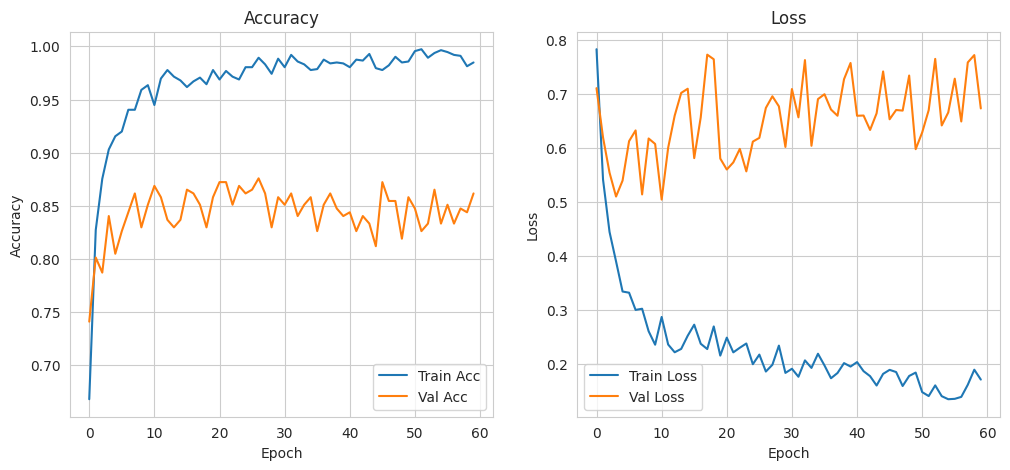

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
Accuracy: 0.8617
Precision: 0.9040
Recall: 0.8791
F1 Score: 0.8914
ROC AUC: 0.9284


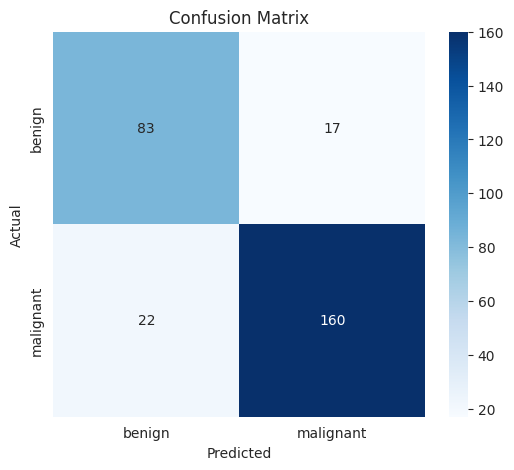

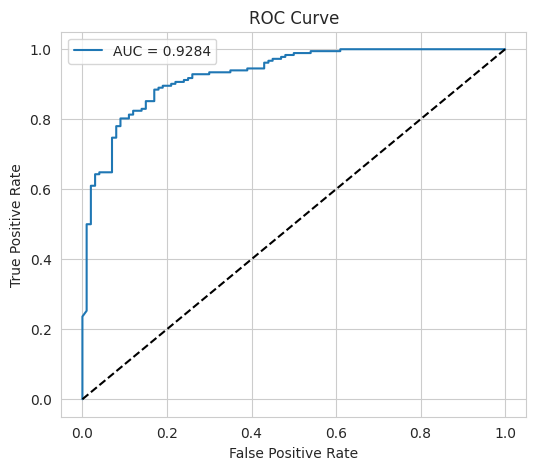


Classification Report:
               precision    recall  f1-score   support

      benign       0.79      0.83      0.81       100
   malignant       0.90      0.88      0.89       182

    accuracy                           0.86       282
   macro avg       0.85      0.85      0.85       282
weighted avg       0.86      0.86      0.86       282



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- Config ----------
INPUT_DIM = X_train.shape[1]
BATCH_SIZE = 16
EPOCHS = 60
LR = 1e-3
DROPOUT_RATE = 0.2

# ---------- Build improved MLP ----------
from tensorflow.keras import layers, models, regularizers

def build_fusion_mlp(input_dim):
    inp = layers.Input(shape=(input_dim,))

    # First layer
    x = layers.Dense(1024, kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)
    x = layers.Dropout(0.3)(x)

    # Second layer
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)
    x = layers.Dropout(0.3)(x)

    # Third layer
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)
    x = layers.Dropout(0.3)(x)

    # Output
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inp, outputs=out)
    return model




from tensorflow.keras import callbacks

model = build_fusion_mlp(X_train.shape[1])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# Class weights for imbalance
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: cw_val for i, cw_val in enumerate(cw)}

cb = [
    callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=16,
    class_weight=class_weights,

    verbose=2
)


# ---------- Plot training curves ----------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ---------- Predict ----------
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# ---------- Metrics ----------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# ---------- Confusion Matrix ----------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------- ROC Curve ----------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ---------- Classification Report ----------
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Random Forest Metrics:
Accuracy: 0.6844, Precision: 0.6742, Recall: 0.9890, F1: 0.8018, ROC AUC: 0.8604


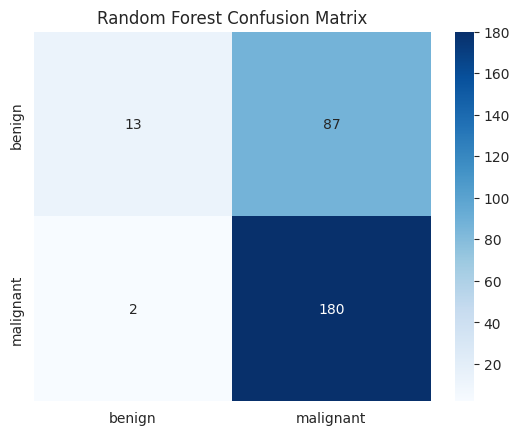

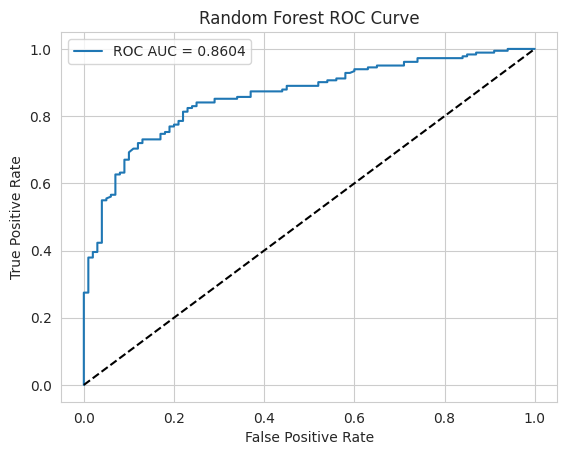

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Random Forest Metrics:\nAccuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:35:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Metrics:
Accuracy: 0.7979, Precision: 0.8141, Recall: 0.8901, F1: 0.8504, ROC AUC: 0.8853


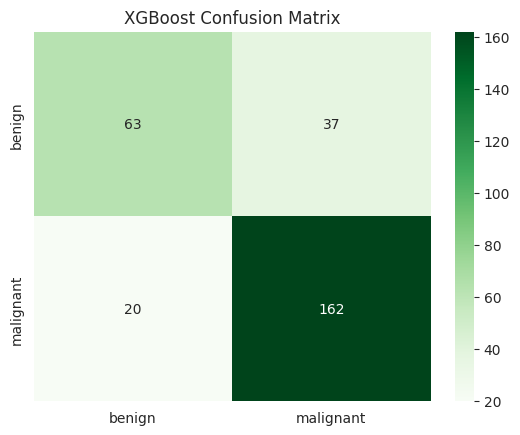

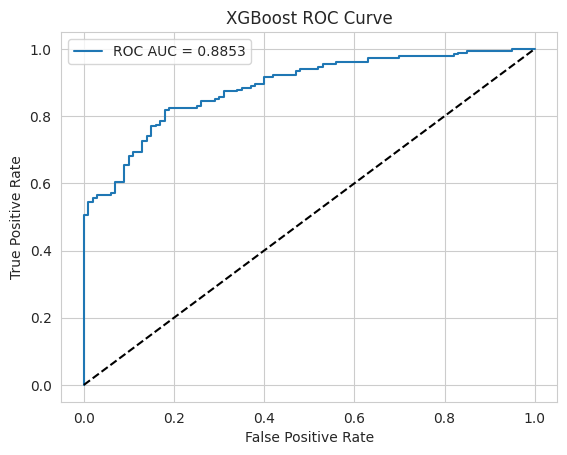

In [32]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # balance classes
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"XGBoost Metrics:\nAccuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()
